# LIME Instability on a Non-Convex Boundary

We pick a single point near the heart's decision boundary and run LIME multiple times with different random seeds. Each run produces a **different explanation direction**, showing that LIME is unstable near curved boundaries. We also show that two very close points get different explanations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from lime.lime_tabular import LimeTabularExplainer
import os, warnings
warnings.filterwarnings('ignore')

## 1. Generate Heart-Shaped Dataset

Boundary: $x^2 + \left(\tfrac{5y}{4} - b\sqrt{|x|}\right)^2 = 1$. Red = inside (+1), blue = outside (-1). A margin around the boundary is discarded to give the SVM a clean separation.

In [2]:
MARGIN = 0.06
SPIKE_DEPTH = 3.0

def _heart_value(x, y):
    return x**2 + (5*y/4 - SPIKE_DEPTH * np.sqrt(np.abs(x)))**2

np.random.seed(42)
n_samples = 50000
raw_x = np.random.uniform(-1.5, 1.5, n_samples)
raw_y = np.random.uniform(-1.0, 2.5, n_samples)

labels = np.full(n_samples, np.nan)
for i in range(n_samples):
    v = _heart_value(raw_x[i], raw_y[i])
    if v < 1 - MARGIN:
        labels[i] = 1.0
    elif v > 1 + MARGIN:
        labels[i] = -1.0

valid = ~np.isnan(labels)
labels_v = labels[valid]
inside_idx = np.where(labels_v == 1.0)[0]
outside_idx = np.where(labels_v == -1.0)[0]
n_min = min(len(inside_idx), len(outside_idx), 1500)

keep_local = np.concatenate([inside_idx[:n_min], outside_idx[:n_min]])
np.random.shuffle(keep_local)
keep_idx = np.where(valid)[0][keep_local]

raw_pts = np.column_stack([raw_x[keep_idx], raw_y[keep_idx]])
RAW_MIN = raw_pts.min(axis=0)
RAW_RANGE = raw_pts.max(axis=0) - RAW_MIN
X = (raw_pts - RAW_MIN) / RAW_RANGE
y = labels_v[keep_local]

print(f"Dataset: {X.shape[0]} points  |  Inside: {int((y==1).sum())}  |  Outside: {int((y==-1).sum())}")

Dataset: 3000 points  |  Inside: 1500  |  Outside: 1500


## 2. Visualize Dataset

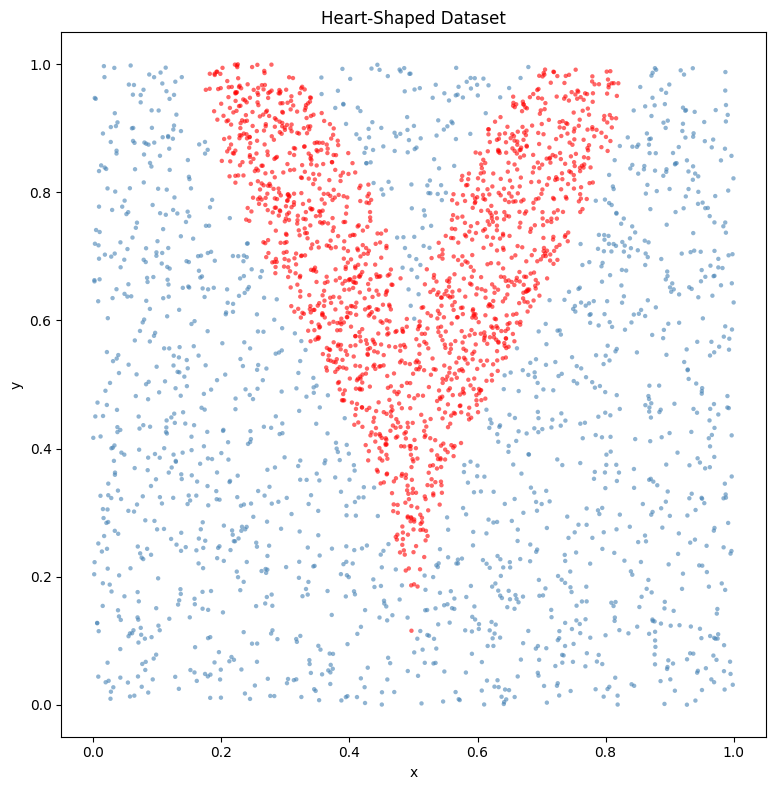

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['red' if label == 1 else 'steelblue' for label in y]
ax.scatter(X[:, 0], X[:, 1], c=colors, s=10, alpha=0.6, edgecolors='none')
ax.set_title('Heart-Shaped Dataset')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 3. Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Train: 2100  |  Test: 900


## 4. Train SVM-RBF

An SVM with RBF kernel gives smooth `predict_proba` values near the boundary. This is important — LIME needs gradual probability changes to fit a meaningful local linear model.

In [5]:
clf = SVC(kernel='rbf', C=100, gamma='scale', probability=True)
clf.fit(X_train, y_train)
clf_acc = accuracy_score(y_test, clf.predict(X_test))
print(f"SVM-RBF accuracy: {clf_acc:.2%}")

SVM-RBF accuracy: 98.44%


## 6. Visualize Decision Boundaries

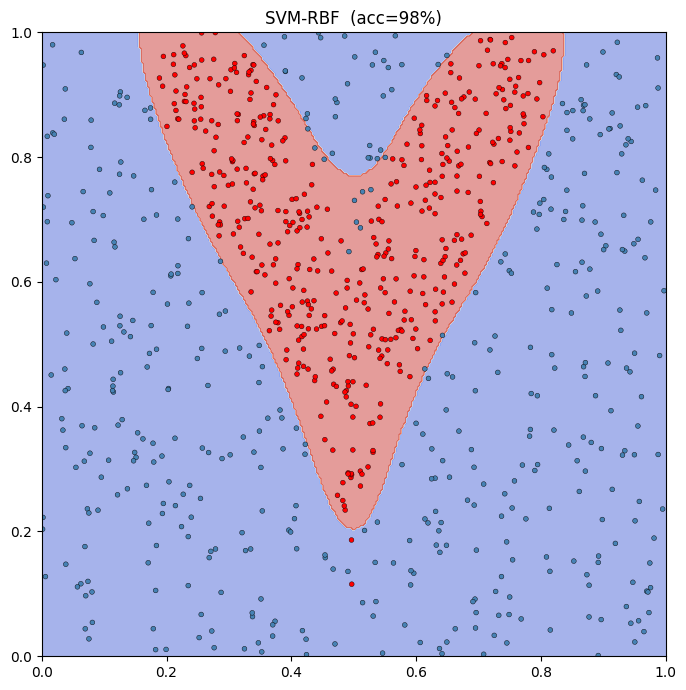

In [6]:
xx, yy = np.meshgrid(np.linspace(0, 1, 300), np.linspace(0, 1, 300))
grid = np.column_stack([xx.ravel(), yy.ravel()])

fig, ax = plt.subplots(figsize=(8, 7))

Z = clf.predict(grid).reshape(xx.shape)
ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.5)
ax.scatter(X_test[:, 0], X_test[:, 1],
           c=['red' if l == 1 else 'steelblue' for l in y_test],
           s=12, edgecolors='k', linewidths=0.3)
ax.set_title(f'SVM-RBF  (acc={clf_acc:.0%})')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 5. Pick a Test Point in the Non-Convex Area

We find the most uncertain test point (probability closest to 0.5) **in the upper part of the heart** — the V-notch region where the boundary is non-convex.

Test point: (0.4527, 0.7965)
SVM probability: outside=0.518  inside=0.482
Nearby point:  (0.4627, 0.7965)  distance=0.01
SVM probability: outside=0.633  inside=0.367


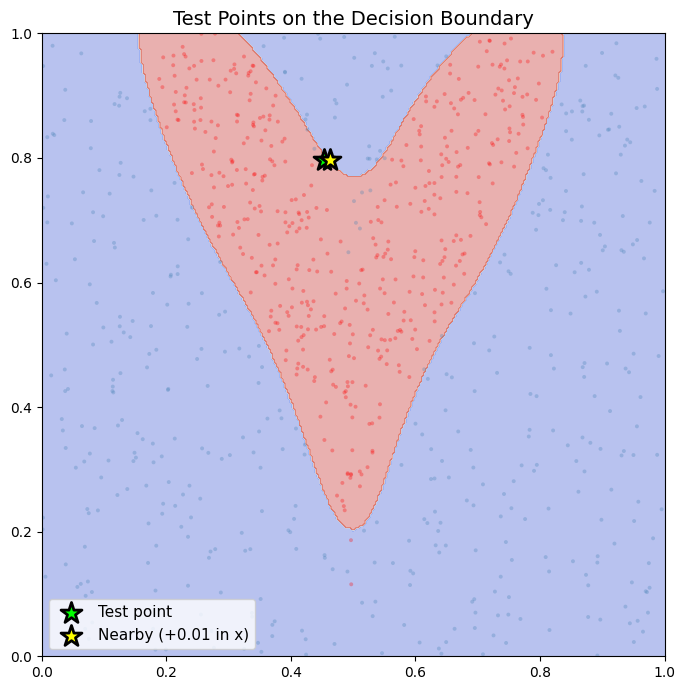

In [7]:
proba_test = clf.predict_proba(X_test)

# Only consider points in the upper region (V-notch area)
upper_mask = X_test[:, 1] > 0.65
uncertainty = np.abs(proba_test[:, 1] - 0.5)
uncertainty[~upper_mask] = 999  # exclude non-upper points
most_uncertain = np.argmin(uncertainty)
test_pt = X_test[most_uncertain]

p = clf.predict_proba(test_pt.reshape(1, -1))[0]
print(f"Test point: ({test_pt[0]:.4f}, {test_pt[1]:.4f})")
print(f"SVM probability: outside={p[0]:.3f}  inside={p[1]:.3f}")

# Also create a second point very close by (nudge in x)
NUDGE = 0.01
test_pt2 = test_pt + np.array([NUDGE, 0])
p2 = clf.predict_proba(test_pt2.reshape(1, -1))[0]
print(f"Nearby point:  ({test_pt2[0]:.4f}, {test_pt2[1]:.4f})  distance={NUDGE}")
print(f"SVM probability: outside={p2[0]:.3f}  inside={p2[1]:.3f}")

fig, ax = plt.subplots(figsize=(8, 7))
Z = clf.predict(grid).reshape(xx.shape)
ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.4)
ax.scatter(X_test[:, 0], X_test[:, 1],
           c=['red' if l == 1 else 'steelblue' for l in y_test],
           s=8, alpha=0.3, edgecolors='none')
ax.scatter(*test_pt, c='lime', s=250, marker='*',
           edgecolors='k', linewidths=2, zorder=10, label='Test point')
ax.scatter(*test_pt2, c='yellow', s=250, marker='*',
           edgecolors='k', linewidths=2, zorder=10, label=f'Nearby (+{NUDGE} in x)')
ax.legend(fontsize=11)
ax.set_title('Test Points on the Decision Boundary', fontsize=14)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 6. Stochastic Instability — Same Point, Different Seeds

We run LIME 20 times on the **same point** with different random seeds and `num_samples=300`. Each run randomly samples perturbation points, leading to a different local linear fit. If LIME were stable, all arrows would agree. They don't.

Angle range: [-2.8, 46.8]
Angle spread: 49.6 degrees
Angle std: 11.4 degrees


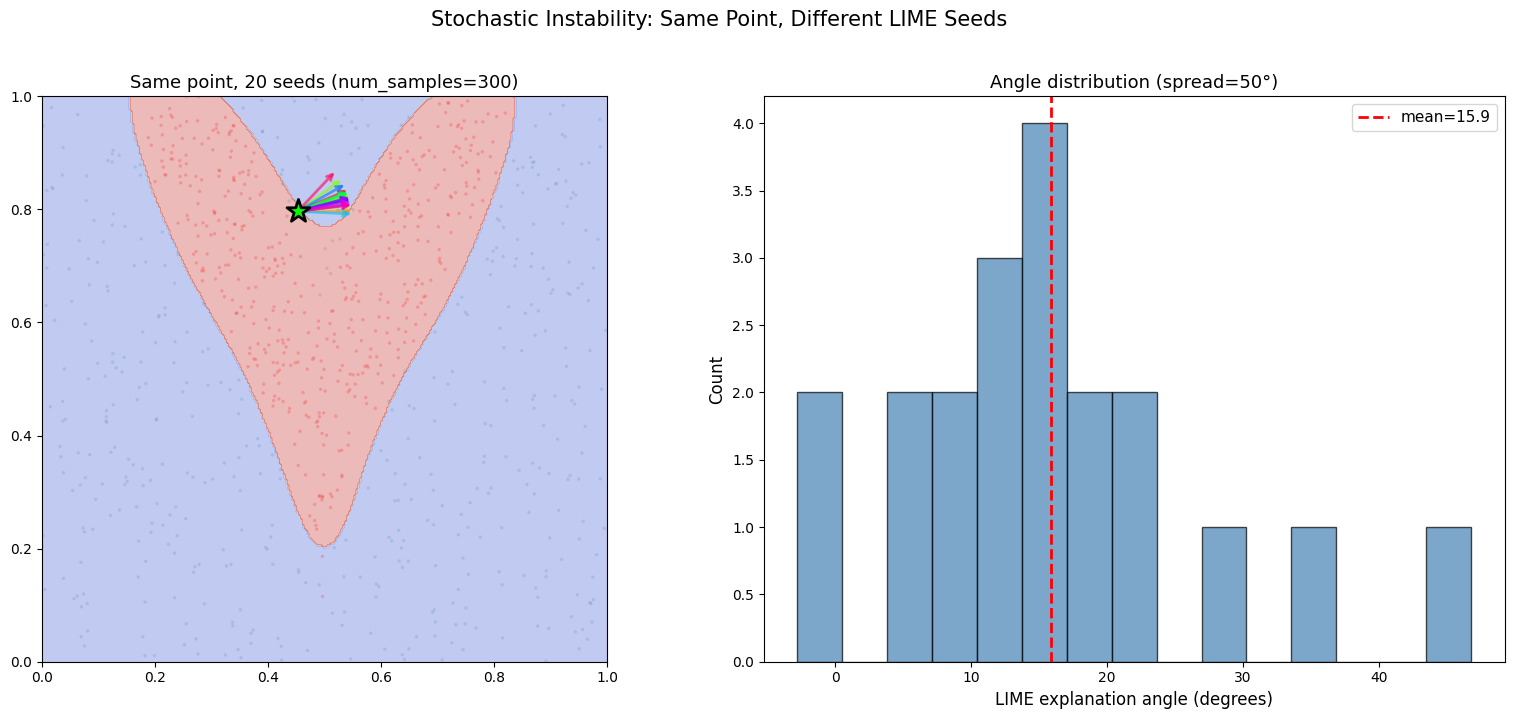

In [8]:
NUM_SAMPLES = 300
N_SEEDS = 20

all_vecs = []
all_angles = []

for seed in range(N_SEEDS):
    exp = LimeTabularExplainer(
        X_train, feature_names=['x', 'y'],
        class_names=['outside (-1)', 'inside (+1)'],
        mode='classification', random_state=seed,
    )
    e = exp.explain_instance(test_pt, clf.predict_proba,
                             num_features=2, num_samples=NUM_SAMPLES)
    v = np.array([dict(e.local_exp[1]).get(i, 0) for i in range(2)])
    all_vecs.append(v)
    all_angles.append(np.degrees(np.arctan2(v[1], v[0])))

all_vecs = np.array(all_vecs)
all_angles = np.array(all_angles)

print(f"Angle range: [{all_angles.min():.1f}, {all_angles.max():.1f}]")
print(f"Angle spread: {all_angles.max() - all_angles.min():.1f} degrees")
print(f"Angle std: {all_angles.std():.1f} degrees")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: arrows from the test point
ax = axes[0]
ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.35)
ax.scatter(X_test[:, 0], X_test[:, 1],
           c=['red' if l == 1 else 'steelblue' for l in y_test],
           s=6, alpha=0.2, edgecolors='none')
for i, v in enumerate(all_vecs):
    scale = 0.10 / (np.linalg.norm(v) + 1e-8)
    ax.annotate('', xy=(test_pt[0]+v[0]*scale, test_pt[1]+v[1]*scale),
                xytext=test_pt,
                arrowprops=dict(arrowstyle='->', lw=2, alpha=0.6,
                                color=plt.cm.hsv(i / N_SEEDS)))
ax.scatter(*test_pt, c='lime', s=300, marker='*',
           edgecolors='k', linewidths=2, zorder=10)
ax.set_title(f'Same point, {N_SEEDS} seeds (num_samples={NUM_SAMPLES})', fontsize=13)
ax.set_aspect('equal')

# Right: angle histogram
ax = axes[1]
ax.hist(all_angles, bins=15, color='steelblue', edgecolor='k', alpha=0.7)
ax.axvline(all_angles.mean(), color='red', lw=2, linestyle='--', label=f'mean={all_angles.mean():.1f}')
ax.set_xlabel('LIME explanation angle (degrees)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Angle distribution (spread={all_angles.max()-all_angles.min():.0f}°)', fontsize=13)
ax.legend(fontsize=11)

plt.suptitle('Stochastic Instability: Same Point, Different LIME Seeds', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 7. Two Close Points — Different Explanations

The nearby point is only 0.01 away. We run LIME on both with the same seed. Even though the points are nearly identical, the explanations differ because tiny position changes shift which perturbation samples cross the boundary.

Point 1 angle std: 11.4°
Point 2 angle std: 14.6°
Mean angle difference: 16.4°
Max angle difference:  34.9°


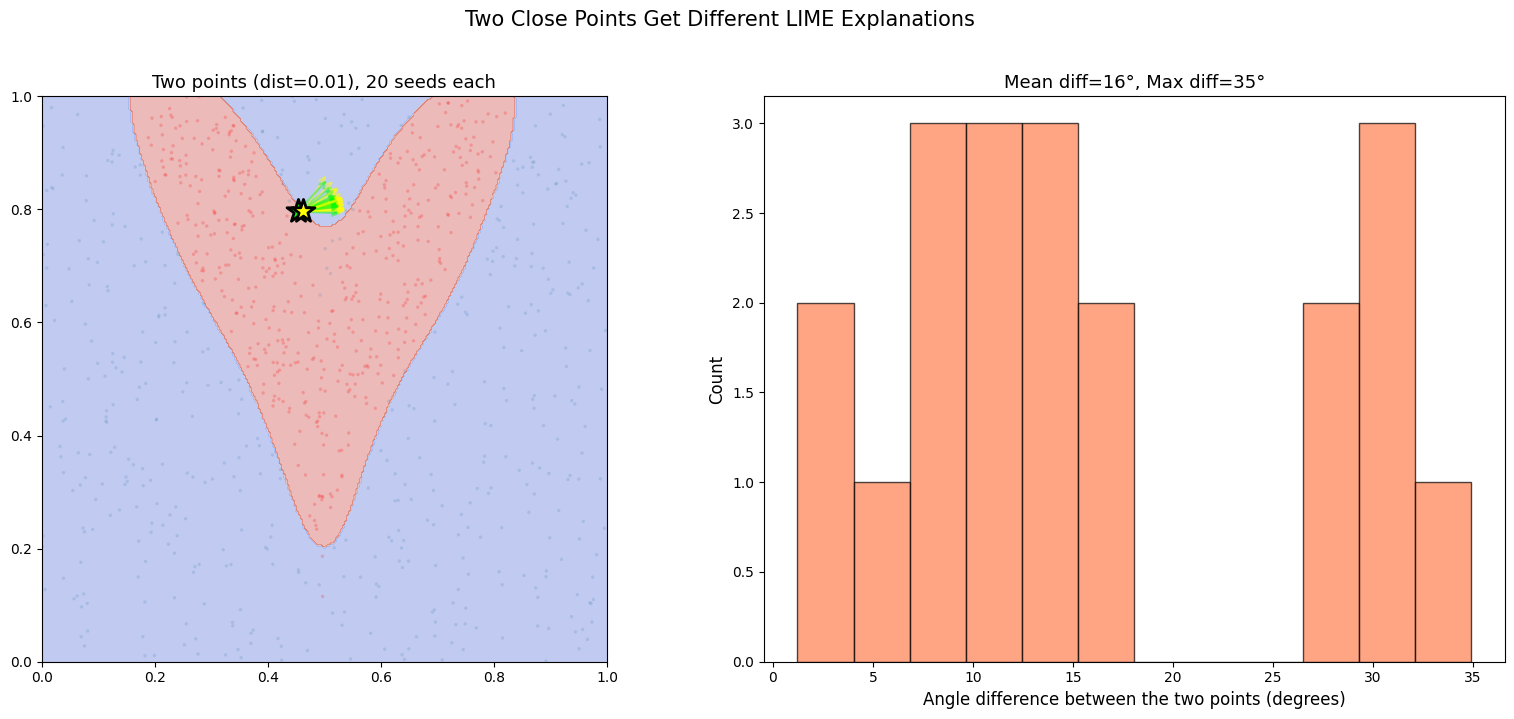

In [9]:
vecs_1, vecs_2 = [], []
angles_1, angles_2 = [], []

for seed in range(N_SEEDS):
    exp = LimeTabularExplainer(
        X_train, feature_names=['x', 'y'],
        class_names=['outside (-1)', 'inside (+1)'],
        mode='classification', random_state=seed,
    )
    for pt, v_store, a_store in [
        (test_pt, vecs_1, angles_1),
        (test_pt2, vecs_2, angles_2),
    ]:
        e = exp.explain_instance(pt, clf.predict_proba,
                                 num_features=2, num_samples=NUM_SAMPLES)
        v = np.array([dict(e.local_exp[1]).get(i, 0) for i in range(2)])
        v_store.append(v)
        a_store.append(np.degrees(np.arctan2(v[1], v[0])))

vecs_1, vecs_2 = np.array(vecs_1), np.array(vecs_2)
angles_1, angles_2 = np.array(angles_1), np.array(angles_2)
angle_diffs = np.abs(angles_1 - angles_2)

print(f"Point 1 angle std: {angles_1.std():.1f}°")
print(f"Point 2 angle std: {angles_2.std():.1f}°")
print(f"Mean angle difference: {angle_diffs.mean():.1f}°")
print(f"Max angle difference:  {angle_diffs.max():.1f}°")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: arrows from both points
ax = axes[0]
ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.35)
ax.scatter(X_test[:, 0], X_test[:, 1],
           c=['red' if l == 1 else 'steelblue' for l in y_test],
           s=6, alpha=0.2, edgecolors='none')

for i in range(N_SEEDS):
    for pt, v, color in [(test_pt, vecs_1[i], 'lime'), (test_pt2, vecs_2[i], 'yellow')]:
        scale = 0.08 / (np.linalg.norm(v) + 1e-8)
        ax.annotate('', xy=(pt[0]+v[0]*scale, pt[1]+v[1]*scale), xytext=pt,
                    arrowprops=dict(arrowstyle='->', lw=1.5, alpha=0.4, color=color))

ax.scatter(*test_pt, c='lime', s=300, marker='*', edgecolors='k', linewidths=2, zorder=10)
ax.scatter(*test_pt2, c='yellow', s=300, marker='*', edgecolors='k', linewidths=2, zorder=10)
ax.set_title(f'Two points (dist={NUDGE}), {N_SEEDS} seeds each', fontsize=13)
ax.set_aspect('equal')

# Right: angle difference histogram
ax = axes[1]
ax.hist(angle_diffs, bins=12, color='coral', edgecolor='k', alpha=0.7)
ax.set_xlabel('Angle difference between the two points (degrees)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Mean diff={angle_diffs.mean():.0f}°, Max diff={angle_diffs.max():.0f}°', fontsize=13)

plt.suptitle('Two Close Points Get Different LIME Explanations', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()